In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv("Spill_Incidents_raw_data.csv")

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543132 entries, 0 to 543131
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Spill Number           543132 non-null  int64  
 1   Program Facility Name  543126 non-null  object 
 2   Street 1               543001 non-null  object 
 3   Street 2               42267 non-null   object 
 4   Locality               542010 non-null  object 
 5   County                 543132 non-null  object 
 6   ZIP Code               51339 non-null   object 
 7   SWIS Code              543132 non-null  int64  
 8   DEC Region             543132 non-null  int64  
 9   Spill Date             542980 non-null  object 
 10  Received Date          542650 non-null  object 
 11  Contributing Factor    543132 non-null  object 
 12  Waterbody              46357 non-null   object 
 13  Source                 543132 non-null  object 
 14  Close Date             532420 non-nu

In [3]:
# 1. Change date columns to datetime datatype
date_columns = ['Spill Date', 'Received Date', 'Close Date']
for col in date_columns:
    data[col] = pd.to_datetime(data[col], errors='coerce')

In [4]:
# 2. Change ZIP Code to numeric and clean entries
# Remove "-" and anything after it, keeping only the numeric part
data['ZIP Code'] = data['ZIP Code'].astype(str).str.split('-').str[0]
data['ZIP Code'] = pd.to_numeric(data['ZIP Code'], errors='coerce').fillna(0).astype(int)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543132 entries, 0 to 543131
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Spill Number           543132 non-null  int64         
 1   Program Facility Name  543126 non-null  object        
 2   Street 1               543001 non-null  object        
 3   Street 2               42267 non-null   object        
 4   Locality               542010 non-null  object        
 5   County                 543132 non-null  object        
 6   ZIP Code               543132 non-null  int64         
 7   SWIS Code              543132 non-null  int64         
 8   DEC Region             543132 non-null  int64         
 9   Spill Date             542980 non-null  datetime64[ns]
 10  Received Date          542650 non-null  datetime64[ns]
 11  Contributing Factor    543132 non-null  object        
 12  Waterbody              46357 non-null   obje

In [6]:
# 3. Sort the dataset by the year from 1900 to 2024
data = data.sort_values(by='Spill Date', ascending=True)

In [7]:
# 4. Remove unwanted redundant columns (Street 1 and Street 2)
data = data.drop(columns=['Street 1', 'Street 2'], errors='ignore')

In [8]:
# 5. Handle missing values
# Fill 'Locality' missing values with "unknown"
data['Locality'].fillna('unknown', inplace=True)

<ipython-input-8-1d852038b95e>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Locality'].fillna('unknown', inplace=True)


In [9]:
# Fill 'ZIP Code' missing values with "0000"
data['ZIP Code'] = data['ZIP Code'].replace(0, '0000')

In [10]:
# Fill 'Waterbody' missing values with "NO WATER BODY AFFECT"
data['Waterbody'].fillna('NO WATER BODY AFFECT', inplace=True)

<ipython-input-10-4f306510bcbc>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Waterbody'].fillna('NO WATER BODY AFFECT', inplace=True)


In [11]:
# Fill missing dates using forward and backward fill
data[['Spill Date', 'Received Date', 'Close Date']] = data[
    ['Spill Date', 'Received Date', 'Close Date']
].ffill().bfill()

In [12]:
# Mode imputation for 'Units' within 'Material Family' and 'Source' groups
data['Units'] = data.groupby(['Material Family', 'Source'])['Units'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Unknown')
)

In [13]:
# Remove rows with null values in the 'Program Facility Name' column
data = data.dropna(subset=['Program Facility Name'])

In [14]:
data.isnull().sum()

,0
Spill Number,0
Program Facility Name,0
Locality,0
County,0
ZIP Code,0
SWIS Code,0
DEC Region,0
Spill Date,0
Received Date,0
Contributing Factor,0


In [15]:
data.shape

(543126, 18)

In [16]:
# Filter out records with Spill Date between 1900 and 1969. Irrelevant older records are removed
filtered_data = data[data['Spill Date'].dt.year >= 1970]

In [17]:
outliers = filtered_data[filtered_data['Spill Date'] > filtered_data['Received Date']]
print(f"Number of outliers found: {len(outliers)}")
print(outliers[['Spill Number', 'Spill Date', 'Received Date']])

Number of outliers found: 1864
        Spill Number Spill Date Received Date
194669       7380219 1974-02-15    1911-11-11
152647       7380306 1974-03-05    1911-11-11
94803        7380312 1974-03-12    1911-11-11
125762       7380302 1974-03-30    1911-11-11
192595       7840432 1974-04-02    1911-11-11
...              ...        ...           ...
530944       8202132 2023-12-06    1982-04-01
533642       8499997 2023-12-06    1984-02-26
534656       8800079 2023-12-06    1988-04-04
535094       8499974 2023-12-06    1984-01-10
539838       8421762 2023-12-06    1984-10-02

[1864 rows x 3 columns]


In [18]:
# Drop rows where Spill Date is after Received Date
filtered_data = filtered_data[filtered_data['Spill Date'] <= filtered_data['Received Date']]

In [19]:
data=filtered_data.copy()

**Start of data visualization **

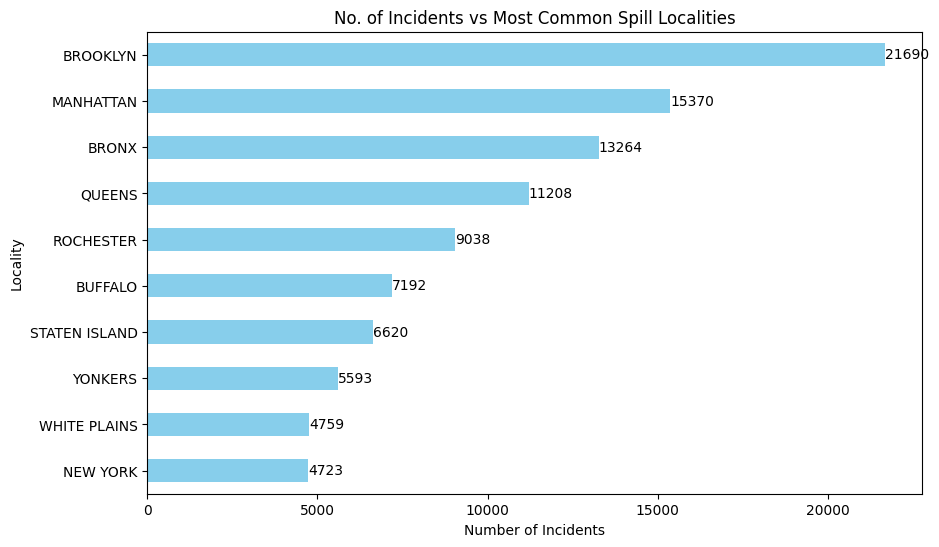

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 1: Most Common Spill Localities (Horizontal Bar Chart)import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame and it has a 'Locality' column
plt.figure(figsize=(10, 6))

# Get the top 10 most common localities
locality_counts = data['Locality'].value_counts().head(10).sort_values()

# Plot the horizontal bar chart
ax = locality_counts.plot(kind='barh', color='skyblue')

# Add count labels to each bar
for index, value in enumerate(locality_counts):
    ax.text(value, index, str(value), va='center', ha='left', color='black')

# Set the title and labels
plt.title('No. of Incidents vs Most Common Spill Localities')
plt.xlabel('Number of Incidents')
plt.ylabel('Locality')

# Show the plot
plt.show()


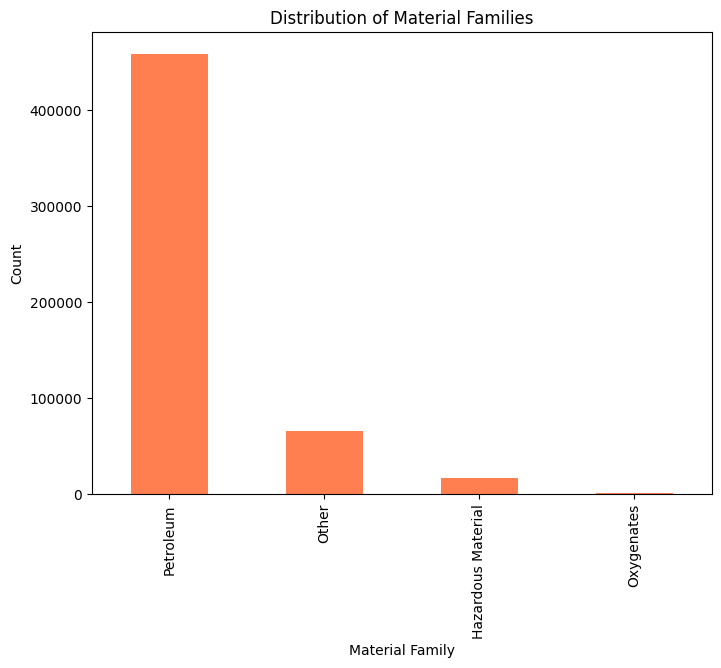

In [21]:
# Visualization 2: Material Families (Bar Chart)
plt.figure(figsize=(8, 6))
data['Material Family'].value_counts().plot(kind='bar', color='coral')
plt.title('Distribution of Material Families')
plt.xlabel('Material Family')
plt.ylabel('Count')
plt.show()

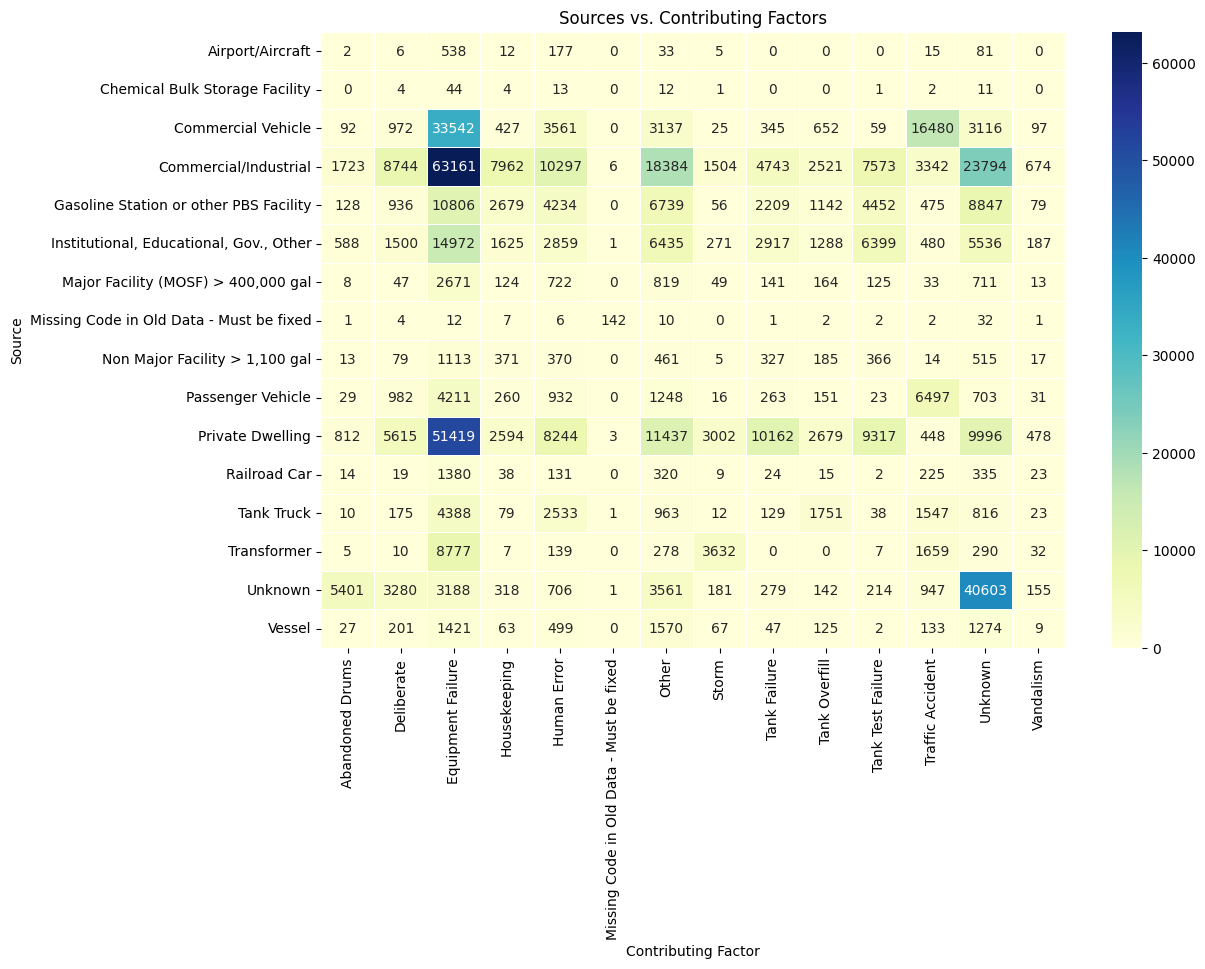

In [22]:
plt.figure(figsize=(12, 8))
heatmap_data = pd.crosstab(data['Source'], data['Contributing Factor'])
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
plt.title('Sources vs. Contributing Factors')
plt.xlabel('Contributing Factor')
plt.ylabel('Source')
plt.show()

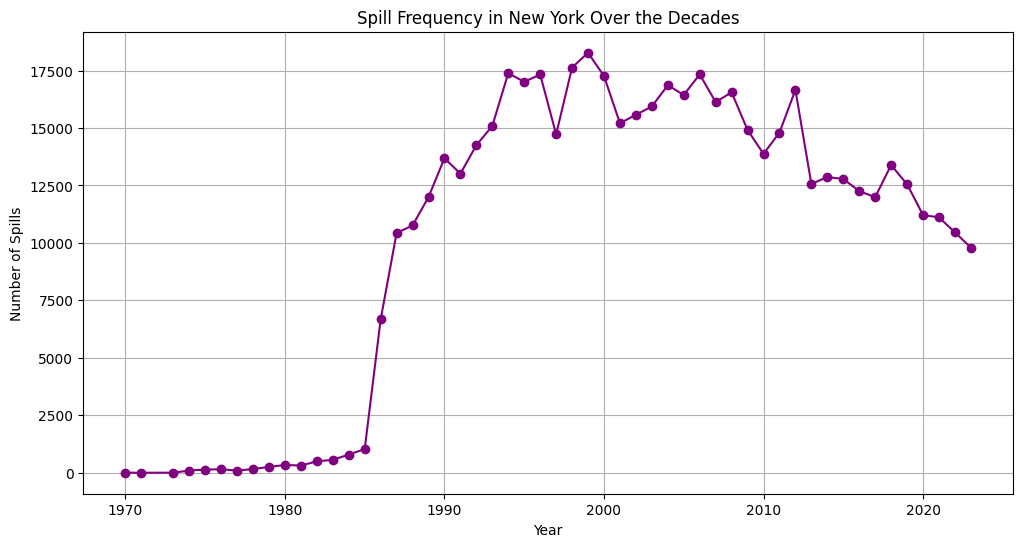

In [23]:
# Visualization 5: Time-Series Analysis (Spill Frequency over Decades)
data['Year'] = pd.to_datetime(data['Spill Date'], errors='coerce').dt.year
spills_per_year = data[data['Year'] >= 1970]['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
spills_per_year.plot(kind='line', marker='o', linestyle='-', color='purple')
plt.title('Spill Frequency in New York Over the Decades')
plt.xlabel('Year')
plt.ylabel('Number of Spills')
plt.grid(True)
plt.show()

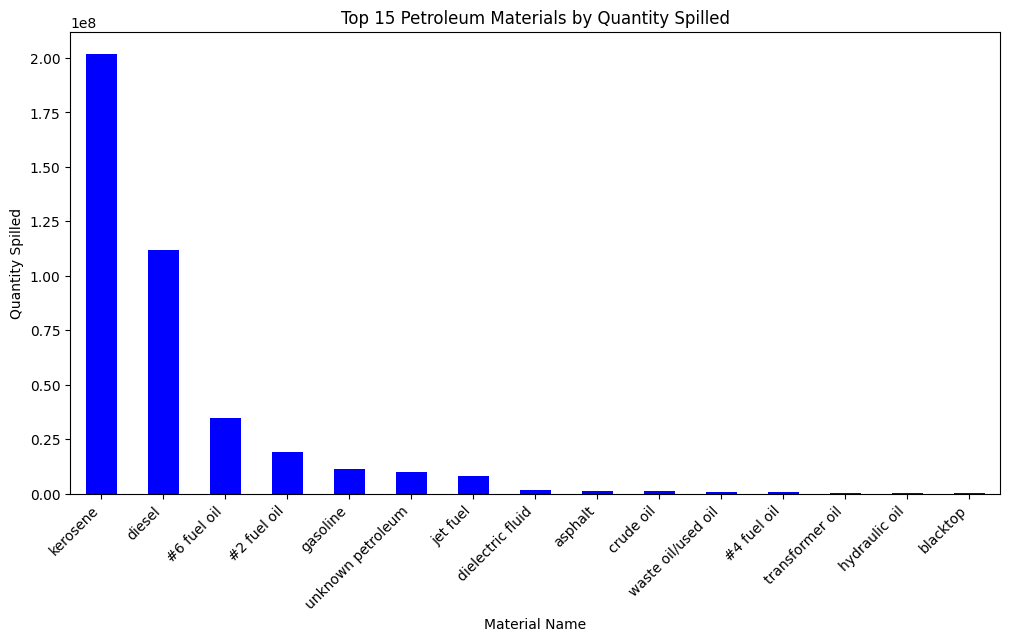

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter the dataset for Petroleum materials only
petroleum_data = data[data['Material Family'] == 'Petroleum']

# Group by 'Material Name' and sum the 'Quantity' spilled
petroleum_spills = petroleum_data.groupby('Material Name')['Quantity'].sum().sort_values(ascending=False)

# Plot the top 15 petroleum materials by quantity spilled
plt.figure(figsize=(12, 6))
petroleum_spills.head(15).plot(kind='bar', color='blue')
plt.title('Top 15 Petroleum Materials by Quantity Spilled')
plt.xlabel('Material Name')
plt.ylabel('Quantity Spilled')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.show()

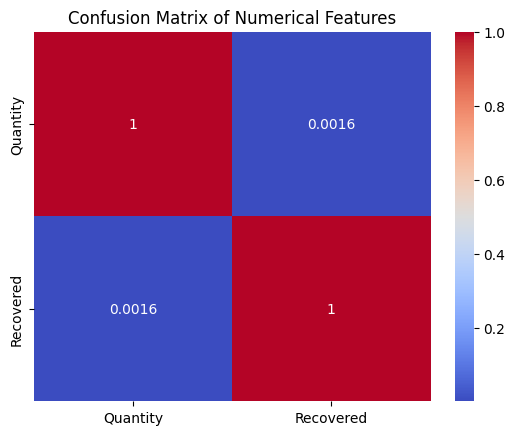

In [25]:
correlation = data[['Quantity', 'Recovered']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Confusion Matrix of Numerical Features')
plt.show()

In [26]:
# Remove rows where 'Quantity' is 0, indicating unknown quantity spilled
data = data[data['Quantity'] != 0]

In [27]:
# Calculate the absolute difference in days between 'Received Date' and 'Spill Date'
data['Date_Difference'] = (data['Received Date'] - data['Spill Date']).abs()

# Convert the difference into number of days
data['Date_Difference_Days'] = data['Date_Difference'].dt.days

# Define the maximum allowed days (5 years)
max_days = 5 * 365  # Approximately 5 years

# Filter out rows where the date gap is more than 5 years
data = data[data['Date_Difference_Days'] <= max_days]

# Drop the helper columns as they are no longer needed
data = data.drop(columns=['Date_Difference', 'Date_Difference_Days'])

<ipython-input-27-fdb7cfd179a2>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Date_Difference'] = (data['Received Date'] - data['Spill Date']).abs()
<ipython-input-27-fdb7cfd179a2>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Date_Difference_Days'] = data['Date_Difference'].dt.days


In [28]:
# Verify no remaining date gaps exceed 5 years
remaining_gaps = (data['Received Date'] - data['Spill Date']).abs().dt.days
print(f"Maximum date gap after filtering: {remaining_gaps.max()} days")

Maximum date gap after filtering: 1825 days


In [29]:
data.shape

(253174, 19)

In [30]:
# Save the cleaned dataset to the specified path
data.to_csv("spill_Incidents_cleaned.csv", index=False)

In [31]:
# Define a function to convert 'Quantity' to gallons if it is in pounds
def convert_to_gallons(row):
    if row['Units'] == 'pounds':
        # Approximate conversion factor for water-like substances
        return row['Quantity'] / 8.3452
    else:
        # If the unit is already in gallons or unknown, leave it as is
        return row['Quantity']

# Apply the conversion to the 'Quantity' column and standardize units to gallons
data['Quantity'] = data.apply(convert_to_gallons, axis=1)
data['Units'] = data['Units'].apply(lambda x: 'gallons' if x == 'pounds' else x)

# Verify the changes
print(data[['Material Family', 'Material Name', 'Quantity', 'Units']].head())

       Material Family Material Name  Quantity    Units
523270       Petroleum   #2 fuel oil    3500.0  Gallons
273544       Petroleum      gasoline    1500.0  Gallons
25778        Petroleum      gasoline     264.0  Gallons
109151       Petroleum   #2 fuel oil     165.0  Gallons
393775       Petroleum   #2 fuel oil     100.0  Gallons


In [32]:
import numpy as np

# Ensure that the dates are in datetime format
data['Spill Date'] = pd.to_datetime(data['Spill Date'], errors='coerce')
data['Close Date'] = pd.to_datetime(data['Close Date'], errors='coerce')

In [33]:
data['Received Date'] = pd.to_datetime(data['Received Date'], errors='coerce')  # Convert Received Date

In [34]:
# Save the cleaned dataset to the specified path
data.to_csv("spill_Incidents_cleaned.csv", index=False)

In [35]:
# Add Spill Duration column in days (using Received Date to Close Date)
data['Spill Duration'] = (data['Close Date'] - data['Received Date']).dt.days

# Remove rows where the Spill Duration is negative
data = data[data['Spill Duration'] >= 0]

In [36]:
data.shape

(251957, 20)

In [37]:
# Add Recovery Efficiency column
data['Recovery Efficiency'] = np.where(data['Quantity'] > 0,
                                       data['Recovered'] / data['Quantity'],
                                       np.nan)  # Avoid division by zero
# Replace any infinity values with NaN (if Quantity was zero)
data['Recovery Efficiency'].replace([np.inf, -np.inf], np.nan, inplace=True)

# Check the new columns
print(data[['Spill Duration', 'Recovery Efficiency']].head())

        Spill Duration  Recovery Efficiency
523270           13592             0.000000
273544               1             0.133333
25778               21             0.000000
109151               1             0.000000
393775               2             0.000000


<ipython-input-37-0faa035766b8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Recovery Efficiency'] = np.where(data['Quantity'] > 0,
<ipython-input-37-0faa035766b8>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Recovery Efficiency'].replace([np.inf, -np.inf], np.nan, in

In [38]:
# Save the cleaned dataset to the specified path
#data.to_csv("/Users/honeythakkar/Downloads/_new_faeture_spill_Incidents.csv", index=False)

In [39]:
# Define the 5-year threshold in days (5 * 365)
max_duration_days = 5 * 365

# Remove rows where the calculated Spill Duration (Received Date to Close Date) exceeds 5 years
data = data[data['Spill Duration'] <= max_duration_days]

In [40]:
data.shape

(244277, 21)

In [41]:
# Save the cleaned dataset to the specified path
#data.to_csv("C:/Users/aishv/Documents/data mining/_new_feature_spill_Incidents_date_gap_5years.csv", index=False)

In [42]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244277 entries, 273544 to 167812
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Spill Number           244277 non-null  int64         
 1   Program Facility Name  244277 non-null  object        
 2   Locality               244277 non-null  object        
 3   County                 244277 non-null  object        
 4   ZIP Code               244277 non-null  object        
 5   SWIS Code              244277 non-null  int64         
 6   DEC Region             244277 non-null  int64         
 7   Spill Date             244277 non-null  datetime64[ns]
 8   Received Date          244277 non-null  datetime64[ns]
 9   Contributing Factor    244277 non-null  object        
 10  Waterbody              244277 non-null  object        
 11  Source                 244277 non-null  object        
 12  Close Date             244277 non-null  date

In [44]:
# Define a function to convert 'Quantity' to gallons if it is in pounds
def convert_to_gallons(row):
    if row['Units'] == 'Pounds':
        # Approximate conversion factor for water-like substances
        return row['Quantity'] / 8.3452
    else:
        # If the unit is already in gallons or unknown, leave it as is
        return row['Quantity']

# Apply the conversion to the 'Quantity' column and standardize units to gallons
data['Quantity'] = data.apply(convert_to_gallons, axis=1)
data['Units'] = data['Units'].apply(lambda x: 'gallons' if x == 'pounds' else x)

# Verify the changes
print(data[['Material Family', 'Material Name', 'Quantity', 'Units']].head())

       Material Family       Material Name  Quantity    Units
273544       Petroleum            gasoline    1500.0  Gallons
25778        Petroleum            gasoline     264.0  Gallons
109151       Petroleum         #2 fuel oil     165.0  Gallons
393775       Petroleum         #2 fuel oil     100.0  Gallons
219582       Petroleum  waste oil/used oil     250.0  Gallons


In [45]:
# Remove rows where Quantity Recovered is greater than Quantity Spilled
data = data[data['Recovered'] <= data['Quantity']]

# Verify that no rows have Quantity Recovered greater than Quantity Spilled
print(f"Rows with Quantity Recovered greater than Quantity Spilled: {(data['Recovered'] > data['Quantity']).sum()}")

Rows with Quantity Recovered greater than Quantity Spilled: 0


In [46]:
data.shape

(243354, 21)

In [47]:
# Update 'Units' to 'gallons' where it was originally in pounds and has been converted
# Check rows with 'Units' as 'Pounds' and 'Quantity' already converted
data.loc[data['Units'] == 'pounds', 'Units'] = 'gallons'

# Verify the change for rows that had 'pounds' initially
print(data[data['Spill Number'] == 7480504][['Spill Number', 'Quantity', 'Units']])

        Spill Number   Quantity   Units
197838       7480504  20.370992  Pounds


In [48]:
# Identify rows that originally had 'pounds' in the Units column but have been converted to gallons
# Update these rows to set 'Units' to 'gallons' where necessary
data.loc[(data['Units'] == 'Pounds') & (data['Quantity'] < 100), 'Units'] = 'gallons'

# Verify the changes for rows that previously had 'Pounds' as the unit
print(data[data['Spill Number'] == 7480504][['Spill Number', 'Quantity', 'Units']])

        Spill Number   Quantity    Units
197838       7480504  20.370992  gallons


In [49]:
# Save the cleaned dataset to the specified path
#data.to_csv("C:/Users/aishv/Documents/data mining/spill_Incidents_cleaned.csv", index=False)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

<ipython-input-51-6ccd3ad4321a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Spill Date'] = pd.to_datetime(data['Spill Date'], errors='coerce')
<ipython-input-51-6ccd3ad4321a>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = data.set_index('Spill Date').resample('M').size()


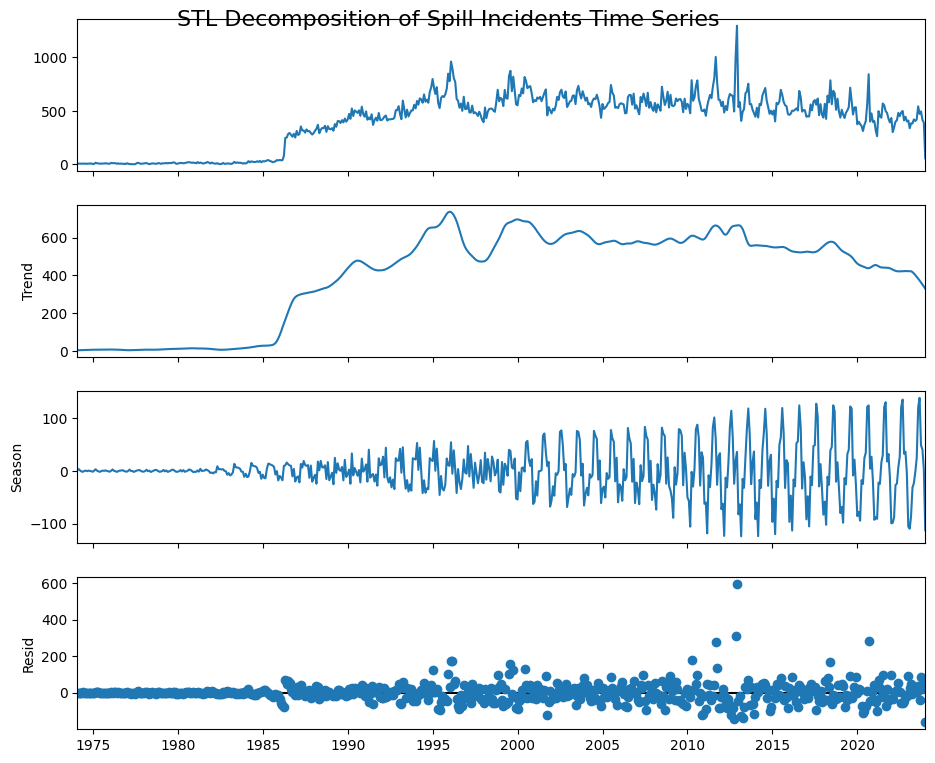

In [51]:
# Ensure 'Spill Date' column is in datetime format
data['Spill Date'] = pd.to_datetime(data['Spill Date'], errors='coerce')

# Drop rows with missing dates if any
data = data.dropna(subset=['Spill Date'])

# Resample the data to get monthly incident counts
monthly_data = data.set_index('Spill Date').resample('M').size()

# STL decomposition with seasonal component set to 13
stl = STL(monthly_data, seasonal=13)
result = stl.fit()

# Plot the STL decomposition
fig = result.plot()
fig.set_size_inches(10, 8)
plt.suptitle('STL Decomposition of Spill Incidents Time Series', fontsize=16)
plt.show()

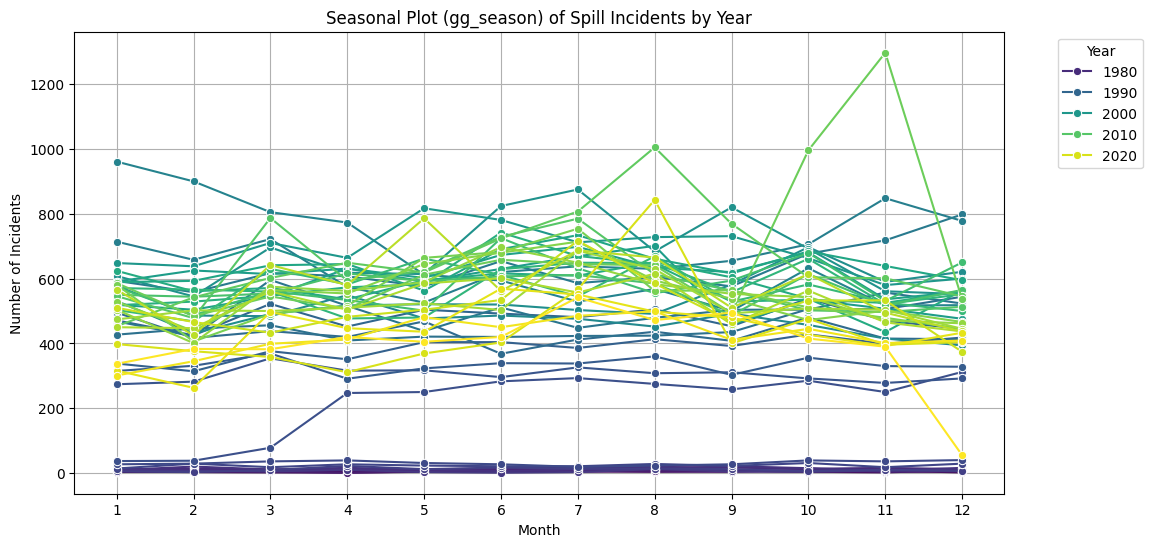

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Extract year and month for seasonal plotting
data['Year'] = data['Spill Date'].dt.year
data['Month'] = data['Spill Date'].dt.month
monthly_data = data.groupby(['Year', 'Month']).size().reset_index(name='Incident_Count')

# gg_season plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Incident_Count', hue='Year', data=monthly_data, palette='viridis', marker='o')
plt.title('Seasonal Plot (gg_season) of Spill Incidents by Year')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

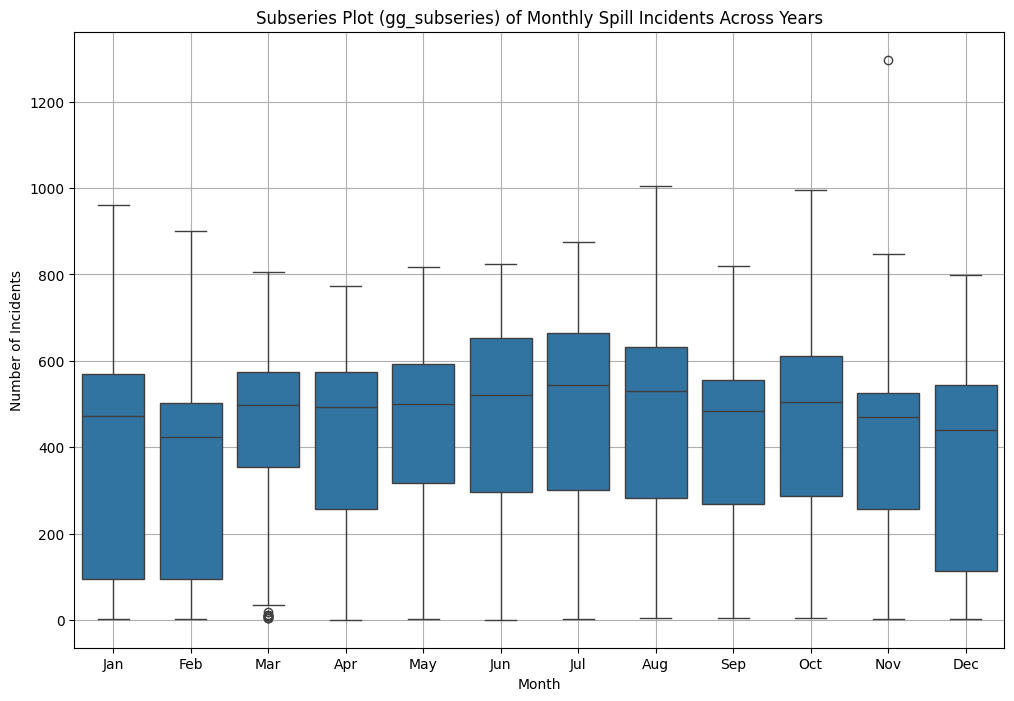

In [53]:
# gg_subseries plot
plt.figure(figsize=(12, 8))
sns.boxplot(x='Month', y='Incident_Count', data=monthly_data)
plt.title('Subseries Plot (gg_subseries) of Monthly Spill Incidents Across Years')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

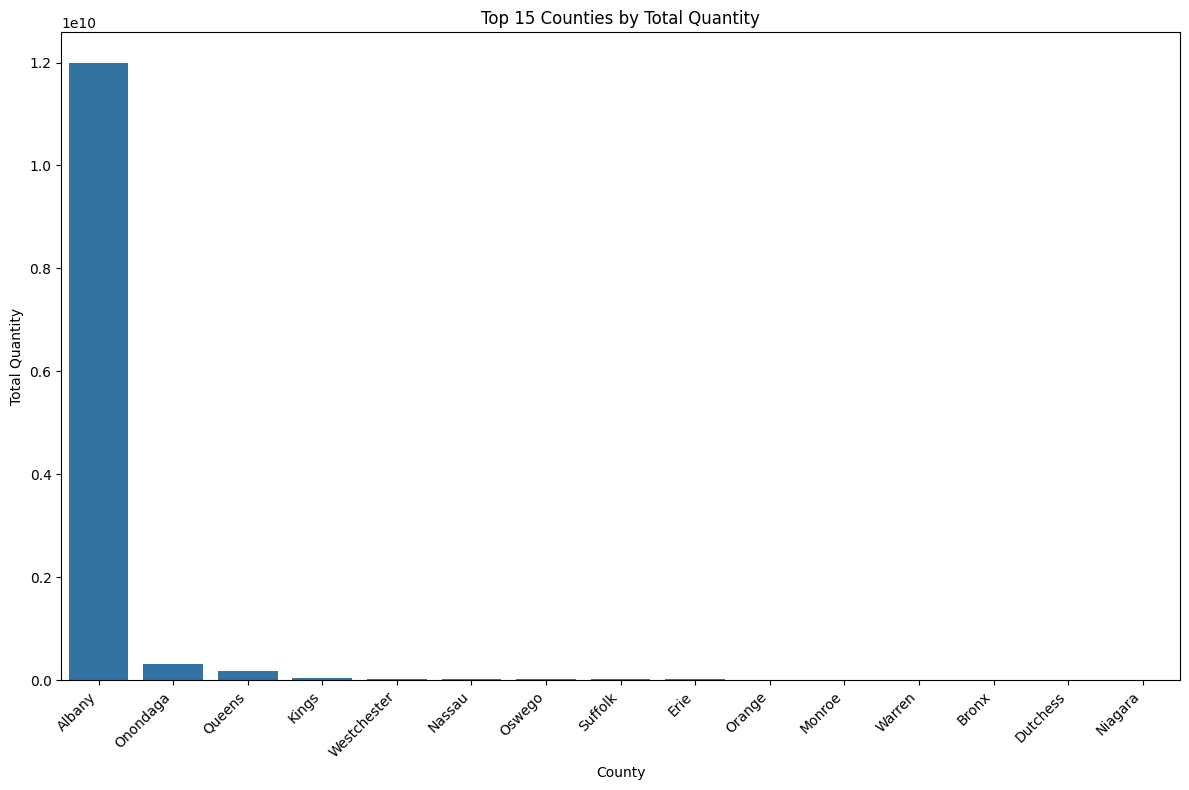

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'monthly_data' contains 'County' and 'Quantity' columns
plt.figure(figsize=(12, 8))

# Aggregate the total Quantity by County and sort it in descending order
top_counties = data.groupby('County')['Quantity'].sum().sort_values(ascending=False).head(15)

# Plotting the barplot for the top 15 counties
sns.barplot(x=top_counties.index, y=top_counties.values)

# Adding titles and labels
plt.title('Top 15 Counties by Total Quantity')
plt.xlabel('County')
plt.ylabel('Total Quantity')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove the grid lines
plt.grid(False)

# Adjust layout to avoid clipping
plt.tight_layout()

# Show the plot
plt.show()


**# plot between Year and Quantity**

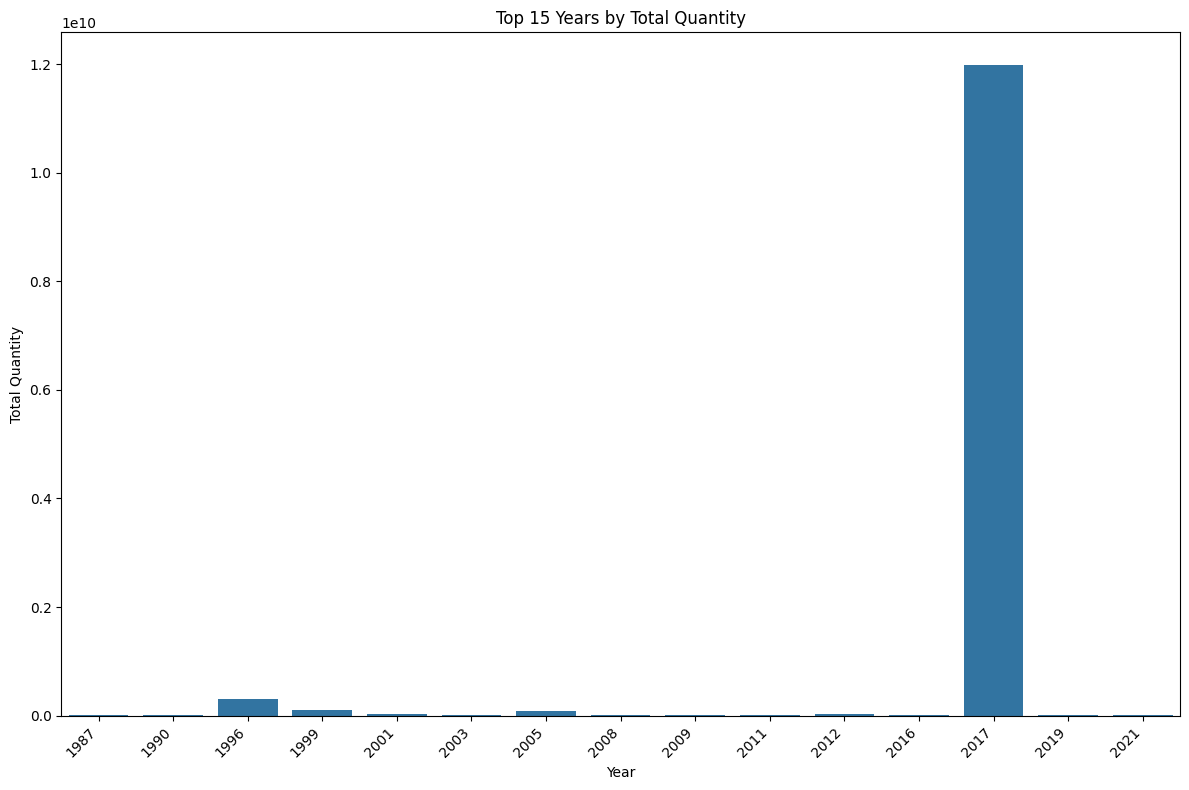

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' contains 'Year' and 'Quantity' columns
plt.figure(figsize=(12, 8))

# Aggregate the total Quantity by County and sort it in descending order
top_counties = data.groupby('Year')['Quantity'].sum().sort_values(ascending=False).head(15)

# Plotting the barplot for the top 15 counties
sns.barplot(x=top_counties.index, y=top_counties.values)

# Adding titles and labels
plt.title('Top 15 Years by Total Quantity')
plt.xlabel('Year')
plt.ylabel('Total Quantity')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove the grid lines
plt.grid(False)

# Adjust layout to avoid clipping
plt.tight_layout()

# Show the plot
plt.show()


**# plot between Zip code and Quantity**

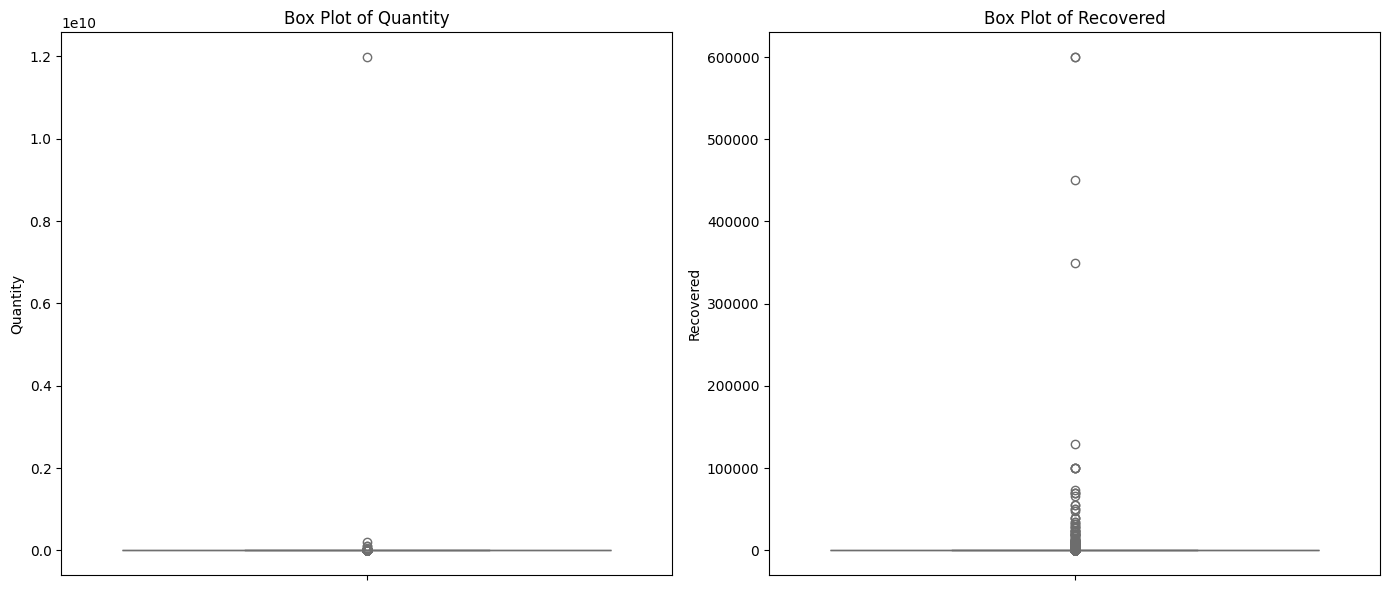

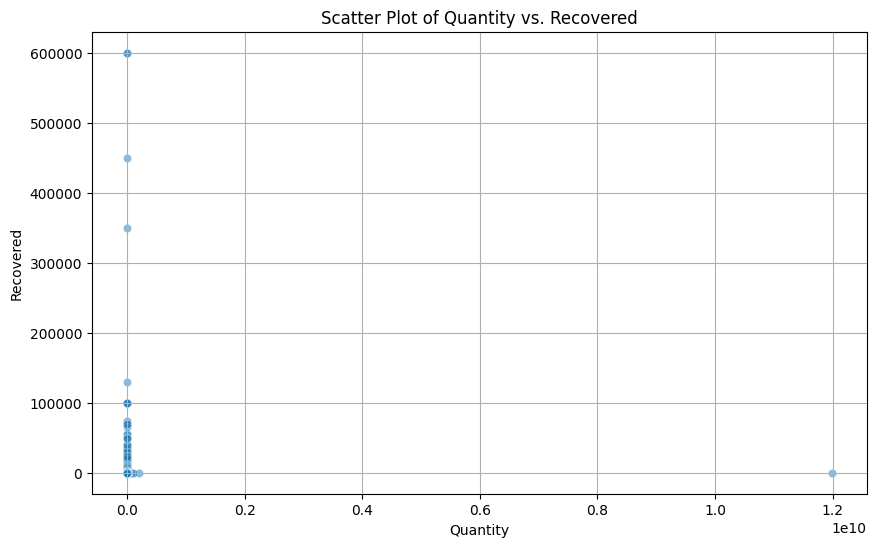

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Box Plot for Quantity and Recovered columns
plt.figure(figsize=(14, 6))

# Box plot for Quantity
plt.subplot(1, 2, 1)
sns.boxplot(y=data['Quantity'], color='skyblue')
plt.title('Box Plot of Quantity')
plt.ylabel('Quantity')

# Box plot for Recovered
plt.subplot(1, 2, 2)
sns.boxplot(y=data['Recovered'], color='salmon')
plt.title('Box Plot of Recovered')
plt.ylabel('Recovered')

plt.tight_layout()
plt.show()

# Scatter Plot to see the relationship between Quantity and Recovered
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='Recovered', data=data, alpha=0.5)
plt.title('Scatter Plot of Quantity vs. Recovered')
plt.xlabel('Quantity')
plt.ylabel('Recovered')
plt.grid()
plt.show()

count    2.433310e+05
mean     4.551210e+02
std      1.552783e+04
min      1.198294e-03
25%      2.000000e+00
50%      6.000000e+00
75%      2.500000e+01
max      2.000000e+06
Name: Quantity, dtype: float64


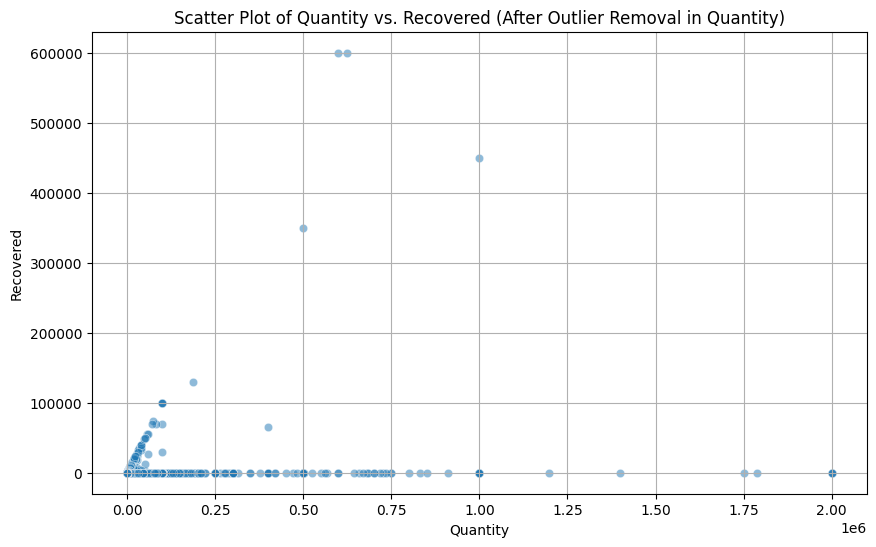

In [57]:
# Define the threshold for Quantity (2,000,000) and filter out values above it
quantity_threshold = 2000000
filtered_data = data[data['Quantity'] <= quantity_threshold]

# Check the summary statistics to confirm the maximum value of Quantity
print(filtered_data['Quantity'].describe())

# Scatter plot to confirm outlier removal in Quantity while retaining Recovered
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='Recovered', data=filtered_data, alpha=0.5)
plt.title('Scatter Plot of Quantity vs. Recovered (After Outlier Removal in Quantity)')
plt.xlabel('Quantity')
plt.ylabel('Recovered')
plt.grid()
plt.show()

In [58]:
data = filtered_data

In [59]:
data.describe()

,Spill Number,SWIS Code,DEC Region,Spill Date,Received Date,Close Date,Quantity,Recovered,Year,Spill Duration,Recovery Efficiency,Month
count,2.433310e+05,243331.000000,243331.000000,243331,243331,243331,2.433310e+05,243331.000000,243331.000000,243331.000000,243331.000000,243331.000000
mean,3.947780e+06,3403.688133,4.065631,2005-04-29 23:09:09.222253056,2005-05-01 19:45:16.285224576,2005-09-17 20:42:14.562386304,4.551210e+02,28.157556,2004.826598,139.039563,0.213347,6.545964
min,1.000000e+00,101.000000,1.000000,1974-01-07 00:00:00,1974-01-23 00:00:00,1974-01-24 00:00:00,1.198294e-03,0.000000,1974.000000,0.000000,0.000000,1.000000
25%,8.081315e+05,2401.000000,2.000000,1996-10-07 00:00:00,1996-10-09 00:00:00,1997-03-11 00:00:00,2.000000e+00,0.000000,1996.000000,1.000000,0.000000,4.000000
50%,1.702355e+06,3300.000000,3.000000,2005-04-17 00:00:00,2005-04-19 00:00:00,2005-08-18 00:00:00,6.000000e+00,0.000000,2005.000000,12.000000,0.000000,7.000000
75%,9.100718e+06,4722.000000,6.000000,2013-09-24 00:00:00,2013-09-25 00:00:00,2014-01-22 00:00:00,2.500000e+01,0.000000,2013.000000,117.000000,0.000000,9.000000
max,9.975754e+06,9700.000000,9.000000,2023-12-05 00:00:00,2023-12-05 00:00:00,2023-12-08 00:00:00,2.000000e+06,600000.000000,2023.000000,1825.000000,1.000000,12.000000
std,3.971131e+06,1681.091499,2.649587,NaN,NaN,NaN,1.552783e+04,2190.387988,10.241339,296.700798,0.404564,3.372650


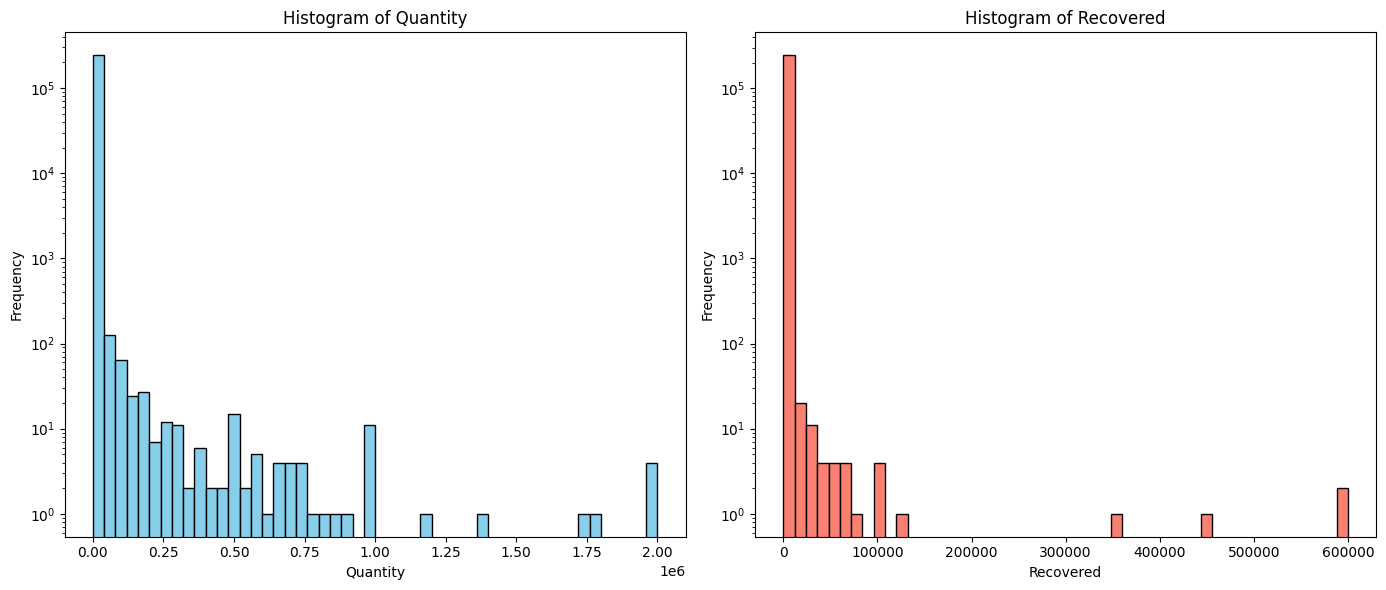

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot histograms for Quantity and Recovered
plt.figure(figsize=(14, 6))

# Histogram for Quantity
plt.subplot(1, 2, 1)
plt.hist(data['Quantity'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.yscale('log')  # Use log scale for better visibility if there's a skew

# Histogram for Recovered
plt.subplot(1, 2, 2)
plt.hist(data['Recovered'], bins=50, color='salmon', edgecolor='black')
plt.title('Histogram of Recovered')
plt.xlabel('Recovered')
plt.ylabel('Frequency')
plt.yscale('log')  # Use log scale for better visibility if there's a skew

plt.tight_layout()
plt.show()

In [61]:
# Save the cleaned dataset to the specified path
#data.to_csv("C:/Users/aishv/Downloads/spill_Incidents_cleaned_outliers.csv", index=False)

In [62]:
data.isnull().sum()

,0
Spill Number,0
Program Facility Name,0
Locality,0
County,0
ZIP Code,0
SWIS Code,0
DEC Region,0
Spill Date,0
Received Date,0
Contributing Factor,0


In [63]:
list11 = ["Program Facility Name", "Locality","County", "Contributing Factor", "Waterbody", "Source", "Material Name", "Material Family" ]

In [64]:
for i in list11:
    print(data[i].value_counts())

Program Facility Name
UNKNOWN                           8942
RESIDENCE                         5030
ROADWAY                           4006
LILCO                             1553
NATIONAL GRID                     1400
                                  ... 
SOUTH DOCK PUMP STATION              1
GEDNEY UNIT SUBSTATION               1
RUSSELL RD @  CENTRAL AVE NIMO       1
ROLLER FELL OFF TRUCK                1
CROKER RESIDENCE                     1
Name: count, Length: 139594, dtype: int64
Locality
BROOKLYN                       9756
MANHATTAN                      8501
QUEENS                         6431
BRONX                          6421
ROCHESTER                      4316
                               ... 
Millerton                         1
fort anne                         1
halfmoon                          1
SCHAGHTICOKE  MECHANICVILLE       1
ZENA                              1
Name: count, Length: 6827, dtype: int64
County
Suffolk                           22748
Nassau         

In [65]:
print (data['Material Name'].value_counts(), "\n",data['Material Name'].value_counts().sum() )

Material Name
#2 fuel oil                                 54665
diesel                                      29455
transformer oil                             26853
hydraulic oil                               23473
gasoline                                    20610
                                            ...  
other  -  Morgoil                               1
other  -  water /fule mix                       1
other  -  Thermalane 600                        1
other  -  Filtrate  Sludge thickening fa        1
other  -  smoke oil                             1
Name: count, Length: 2823, dtype: int64 
 243331


In [66]:
from sklearn.preprocessing import LabelEncoder

# Initialize the Label Encoder
label_encoder = LabelEncoder()

# Apply label encoding to the specified columns
columns_to_encode = ["Program Facility Name", "Locality","County", "Contributing Factor", "Waterbody", "Source", "Material Name", "Material Family"]

for col in columns_to_encode:
    data[col] = label_encoder.fit_transform(data[col])

# Check the first few rows to verify encoding
print(data[columns_to_encode].head())

        Program Facility Name  Locality  County  Contributing Factor  \
273544                  73173      4036      32                    6   
25778                    9761      3692      47                   11   
109151                  29839      1191      32                    8   
393775                 102238      1241      69                    2   
219582                  56187      4678      64                   12   

        Waterbody  Source  Material Name  Material Family  
273544       1058       4            458                3  
25778        1775      12            458                3  
109151        557      10              0                3  
393775        500      12              0                3  
219582       1869      14           2787                3  


**# Just checking the type of the columns and unique values in the columns before performing Non - Hierarchical and Hierarchical clustering.**

In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243331 entries, 273544 to 167812
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Spill Number           243331 non-null  int64         
 1   Program Facility Name  243331 non-null  int64         
 2   Locality               243331 non-null  int64         
 3   County                 243331 non-null  int64         
 4   ZIP Code               243331 non-null  object        
 5   SWIS Code              243331 non-null  int64         
 6   DEC Region             243331 non-null  int64         
 7   Spill Date             243331 non-null  datetime64[ns]
 8   Received Date          243331 non-null  datetime64[ns]
 9   Contributing Factor    243331 non-null  int64         
 10  Waterbody              243331 non-null  int64         
 11  Source                 243331 non-null  int64         
 12  Close Date             243331 non-null  date

In [68]:
# Adjust settings to display all columns
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)       # Adjust display width for wrapping
# Print the dataset
print(data.head(len(data)))

        Spill Number  Program Facility Name  Locality  County ZIP Code  SWIS Code  DEC Region  \
273544       7380123                  73173      4036      32    14517       2640           8   
25778        7380124                   9761      3692      47    14512       3538           8   
109151       7380129                  29839      1191      32    14435       2624           8   
393775       7380204                 102238      1241      69    14830       5138           8   
219582       7390211                  56187      4678      64     0000       4932           8   
...              ...                    ...       ...     ...      ...        ...         ...   
439962       2307342                 112459       658      21     0000       1502           9   
400457       2307355                 103313      3821       2    10465        301           2   
135012       2307338                  36041      3197      79     0000       5928           8   
321337       2307340          

In [69]:
# Find unique values for each column
unique_values = {col: data[col].unique() for col in data.columns}

# Print unique values for each column
for col, values in unique_values.items():
    print(f"Column: {col}")
    print(f"Unique Values: {values}\n")

Column: Spill Number
Unique Values: [7380123 7380124 7380129 ... 2307338 2307340 2307352]

Column: Program Facility Name
Unique Values: [ 73173   9761  29839 ... 112459  36041  86981]

Column: Locality
Unique Values: [4036 3692 1191 ... 6575 6627 6741]

Column: County
Unique Values: [32 47 69 64 65 79 35 82 25 49 11 44 67 28 45 21 81 77 23 61 10 22 24 42
 78 13 58 37 70 26  9 62  0 50 29  1 80 14  7 33 18 73 12 31 48 75 60 71
  3 20 30 38 36 57 59 41 56 63  2 72 51 19 27  4 34 52 68  8 15  5 76  6
 54 55 39 16 17 53 40 46 66 74 43]

Column: ZIP Code
Unique Values: [14517 14512 14435 ... 12546 12827 10707]

Column: SWIS Code
Unique Values: [2640 3538 2624 ... 9600 1232 4200]

Column: DEC Region
Unique Values: [8 6 7 9 5 4 1 3 2]

Column: Spill Date
Unique Values: <DatetimeArray>
['1974-01-07 00:00:00', '1974-01-24 00:00:00', '1974-01-29 00:00:00', '1974-02-04 00:00:00',
 '1974-02-11 00:00:00', '1974-02-13 00:00:00', '1974-02-18 00:00:00', '1974-02-19 00:00:00',
 '1974-03-05 00:00:00', '

**# Non-Hierarchical clustering**

In [70]:
# Export the dataset to a new CSV file
data.to_csv("/content/final_cleaned_dataset.csv", index=False)

In [71]:
from scipy.stats import zscore
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# Assuming your dataset is in a pandas DataFrame called df
# Select the features you want to consider for clustering
X = data.select_dtypes(include=[np.number])  # Select only numeric columns

# Standardize the data to ensure equal weight for all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute the Z-scores
z_scores = np.abs(zscore(X_scaled))

# Define a threshold to identify outliers
threshold = 3  # Z-score above this value is considered an outlier
outliers = (z_scores > threshold).all(axis=1)  # Outliers across all features


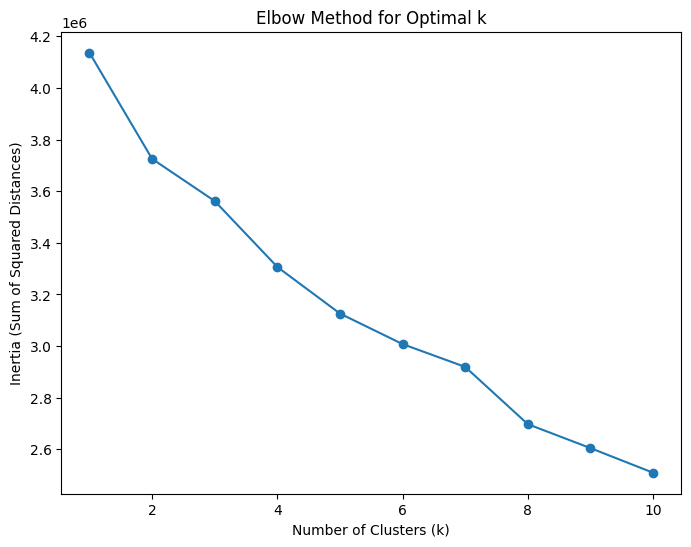

In [72]:
# Elbow Method to find optimal number of clusters
inertia = []  # List to store the inertia (sum of squared distances)

# Test for a range of cluster numbers (e.g., from 1 to 10)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.show()


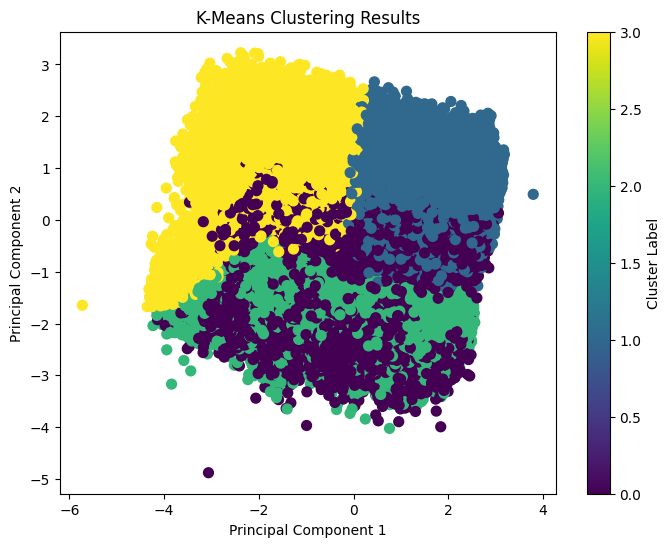

In [73]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming your dataset is in a pandas DataFrame called df
# Select only numeric columns for clustering
X = data.select_dtypes(include=[np.number])  # Only numeric features

# Remove the outliers
X_no_outliers = X[~outliers]

# Standardize the data to ensure equal weight for all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_outliers)

# Perform K-means clustering (adjust n_clusters as needed)
kmeans = KMeans(n_clusters=4, random_state=42)  # Set n_clusters as desired
kmeans.fit(X_scaled)

# Get the cluster labels
labels = kmeans.labels_

# Apply PCA to reduce the data to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', marker='o', s=50)
plt.title('K-Means Clustering Results')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()


**# Hierarchical Clustering**

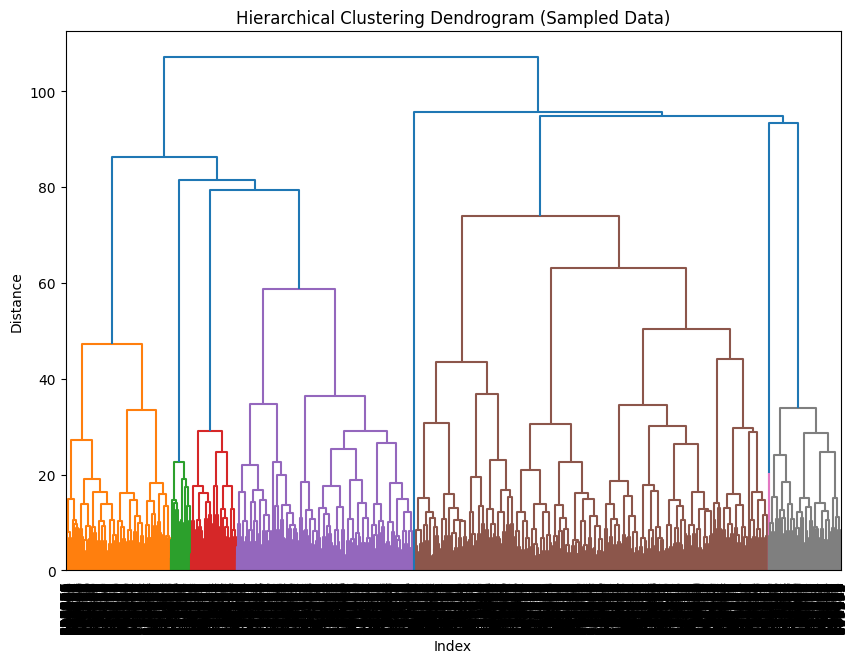

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

# Randomly sample 5,000 rows for clustering
data_sampled = data.sample(n=5000, random_state=42)

# Select numeric columns and proceed as before
numeric_data = data_sampled.select_dtypes(include=['number'])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numeric_data)

linked = linkage(data_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, labels=data_sampled.index, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Sampled Data)')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()

